# 01 – Exploratory Data Analysis
Utforsking av IRMAS-datasettet: klassefordeling, lydkarakteristikker, eksempel-spektrogrammer.

In [19]:
# ============================================================
# 01_eda.ipynb  –  Download, explore & sanity check IRMAS
# ============================================================

# --- 1. Installer avhengigheter ---
!pip install librosa zenodo_get -q

from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive allerede montert!")

Drive allerede montert!


In [21]:
# --- 2. Last ned og pakk ut IRMAS treningsdata ---
import os
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/IRMAS")
ZIP_PATH  = DRIVE_DIR / "IRMAS-TrainingData.zip"
DATA_DIR  = DRIVE_DIR / "IRMAS-TrainingData"

DRIVE_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    print("Laster ned treningsdata (~3.2 GB) ...")
    !wget -O {ZIP_PATH} "https://zenodo.org/records/1290750/files/IRMAS-TrainingData.zip?download=1"
else:
    print("Zip-fil finnes allerede:", ZIP_PATH)

Laster ned treningsdata (~3.2 GB) ...
--2026-04-16 14:26:51--  https://zenodo.org/records/1290750/files/IRMAS-TrainingData.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.48.75, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3181049879 (3.0G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip’

/content/drive/MyDr 100%[===================>]   2.96G  15.2MB/s    in 13m 43s 

2026-04-16 14:40:35 (3.69 MB/s) - ‘/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip’ saved [3181049879/3181049879]



In [28]:
# --- 3. Klassefordeling ---
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip")
OUT_DIR  = Path("/content/drive/MyDrive/IRMAS")

print("Pakker ut... (tar noen minutter)")
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)
print("Ferdig!")

Pakker ut... (tar noen minutter)
Ferdig!


Antall klasser : 11
Klasser        : ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
Totalt klipp   : 6705


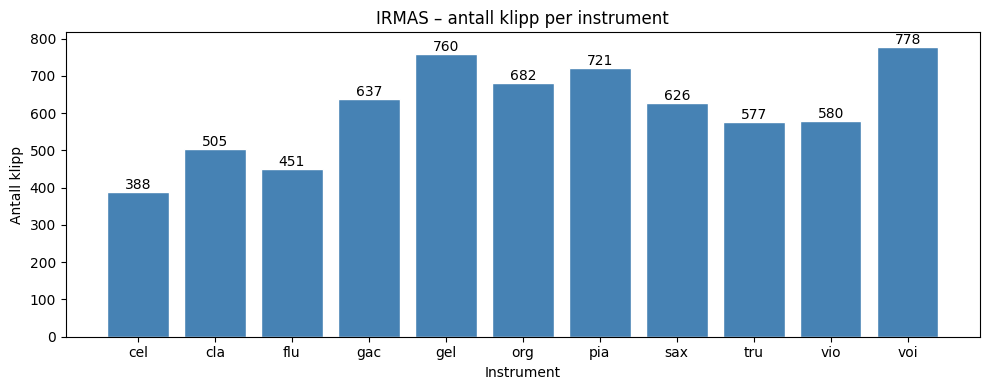

In [29]:
# --- 3. Klassefordeling ---
import numpy as np
import matplotlib.pyplot as plt

classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
counts  = {c: len(list((DATA_DIR / c).glob("*.wav"))) for c in classes}

print(f"Antall klasser : {len(classes)}")
print(f"Klasser        : {classes}")
print(f"Totalt klipp   : {sum(counts.values())}")

plt.figure(figsize=(10, 4))
bars = plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
plt.bar_label(bars)
plt.title("IRMAS – antall klipp per instrument")
plt.ylabel("Antall klipp")
plt.xlabel("Instrument")
plt.tight_layout()
plt.show()

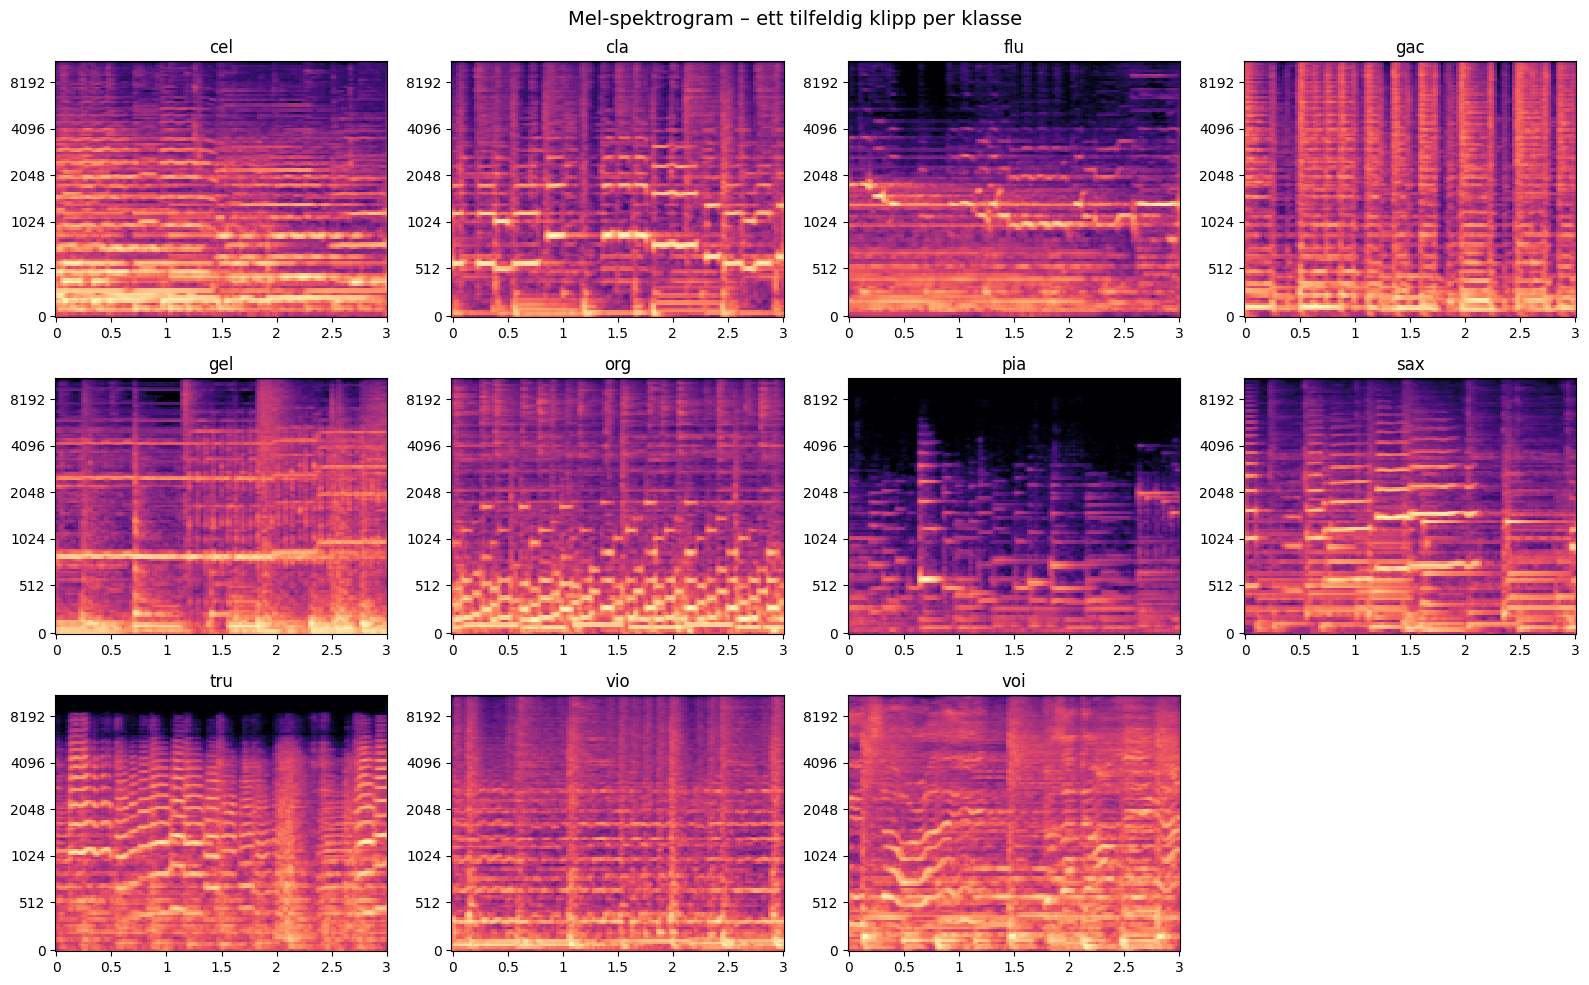

In [30]:
# --- 4. Vis mel-spektrogram for ett klipp per klasse ---
import random
import librosa
import librosa.display

SR         = 22050
N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = random.choice(list((DATA_DIR / cls).glob("*.wav")))
    y, sr  = librosa.load(sample, sr=SR, mono=True)
    S      = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db   = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i])
    axes[i].set_title(cls)
    axes[i].set_xlabel(""); axes[i].set_ylabel("")

# Skjul tom siste rute (11 klasser, 12 ruter)
axes[-1].set_visible(False)

fig.suptitle("Mel-spektrogram – ett tilfeldig klipp per klasse", fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# --- 5. Sanity check: klipplengde og sample rate ---
print("Sjekker klipplengde og sample rate (20 klipp per klasse) ...")

lengths_sec = []
sample_rates = []

for cls in classes:
    filer = list((DATA_DIR / cls).glob("*.wav"))[:20]
    for f in filer:
        y, sr = librosa.load(f, sr=None)   # sr=None = original sample rate
        lengths_sec.append(len(y) / sr)
        sample_rates.append(sr)

print(f"Klipplengde  – min: {min(lengths_sec):.2f}s  "
      f"max: {max(lengths_sec):.2f}s  "
      f"mean: {np.mean(lengths_sec):.2f}s")
print(f"Sample rates – ulike verdier: {set(sample_rates)}")

Sjekker klipplengde og sample rate (20 klipp per klasse) ...
Klipplengde  – min: 3.00s  max: 3.00s  mean: 3.00s
Sample rates – ulike verdier: {44100}


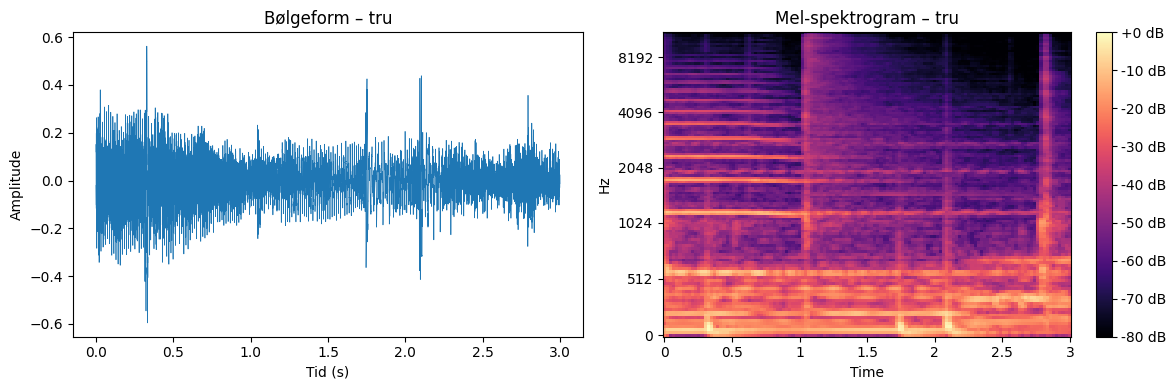

In [32]:
# --- 6. Vis bølgeform + spektrogram side om side for ett klipp ---
cls_demo = "tru"   # bytt til ønsket klasse
sample   = random.choice(list((DATA_DIR / cls_demo).glob("*.wav")))

y, sr = librosa.load(sample, sr=SR, mono=True)
S     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_db  = librosa.power_to_db(S, ref=np.max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bølgeform
ax1.plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
ax1.set_title(f"Bølgeform – {cls_demo}")
ax1.set_xlabel("Tid (s)"); ax1.set_ylabel("Amplitude")

# Mel-spektrogram
img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                x_axis='time', y_axis='mel', ax=ax2)
fig.colorbar(img, ax=ax2, format='%+2.0f dB')
ax2.set_title(f"Mel-spektrogram – {cls_demo}")

plt.tight_layout()
plt.show()

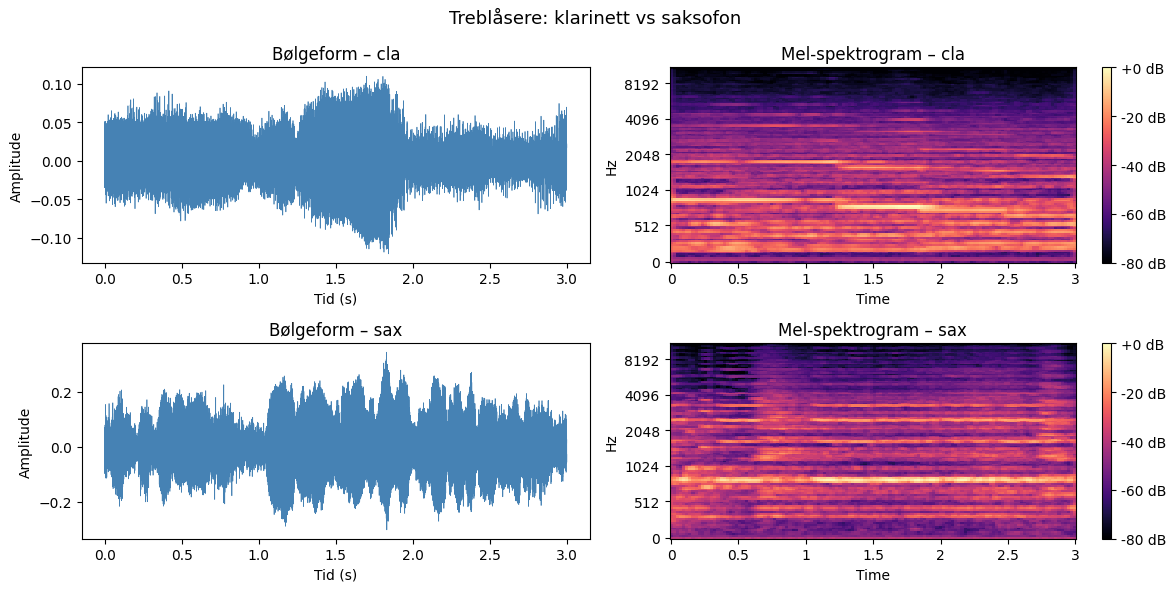

In [33]:
# --- 7. Sammenlign to instrumenter med lik klangfamilie ---
# Treblåsere: klarinett vs saksofon
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for row, cls in enumerate(["cla", "sax"]):
    sample = random.choice(list((DATA_DIR / cls).glob("*.wav")))
    y, sr  = librosa.load(sample, sr=SR, mono=True)
    S      = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db   = librosa.power_to_db(S, ref=np.max)

    axes[row, 0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5, color='steelblue')
    axes[row, 0].set_title(f"Bølgeform – {cls}")
    axes[row, 0].set_xlabel("Tid (s)"); axes[row, 0].set_ylabel("Amplitude")

    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[row, 1])
    fig.colorbar(img, ax=axes[row, 1], format='%+2.0f dB')
    axes[row, 1].set_title(f"Mel-spektrogram – {cls}")

fig.suptitle("Treblåsere: klarinett vs saksofon", fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
# --- 8. Oppsummering ---
print("=" * 45)
print("IRMAS EDA – oppsummering")
print("=" * 45)
print(f"Klasser     : {len(classes)}")
print(f"Totalt klipp: {sum(counts.values())}")
print(f"Minste klasse: {min(counts, key=counts.get)} ({min(counts.values())} klipp)")
print(f"Største klasse: {max(counts, key=counts.get)} ({max(counts.values())} klipp)")
print(f"Klipplengde : ~{np.mean(lengths_sec):.1f}s (alle klipp er 3s)")
print(f"Sample rate : {set(sample_rates)}")
print()
print("Klar for preprocessing! Kjør 02_preprocessing.ipynb")

IRMAS EDA – oppsummering
Klasser     : 11
Totalt klipp: 6705
Minste klasse: cel (388 klipp)
Største klasse: voi (778 klipp)
Klipplengde : ~3.0s (alle klipp er 3s)
Sample rate : {44100}

Klar for preprocessing! Kjør 02_preprocessing.ipynb
